In [2]:
#importing the Libraies
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Reading the Dataset
dataset = pd.read_csv('CKD.csv')

In [4]:
dataset

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,2.000000,76.459948,c,3.0,0.0,normal,abnormal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,yes,no,yes
1,3.000000,76.459948,c,2.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,34.000000,12300.000000,4.705597,no,no,no,yes,poor,no,yes
2,4.000000,76.459948,a,1.0,0.0,normal,normal,notpresent,notpresent,99.000000,...,34.000000,8408.191126,4.705597,no,no,no,yes,poor,no,yes
3,5.000000,76.459948,d,1.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,poor,yes,yes
4,5.000000,50.000000,c,0.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,36.000000,12400.000000,4.705597,no,no,no,yes,poor,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,a,0.0,0.0,normal,normal,notpresent,notpresent,219.000000,...,37.000000,9800.000000,4.400000,no,no,no,yes,poor,no,yes
395,51.492308,70.000000,c,0.0,2.0,normal,normal,notpresent,notpresent,220.000000,...,27.000000,8408.191126,4.705597,yes,yes,no,yes,poor,yes,yes
396,51.492308,70.000000,c,3.0,0.0,normal,normal,notpresent,notpresent,110.000000,...,26.000000,9200.000000,3.400000,yes,yes,no,poor,poor,no,yes
397,51.492308,90.000000,a,0.0,0.0,normal,normal,notpresent,notpresent,207.000000,...,38.868902,8408.191126,4.705597,yes,yes,no,yes,poor,yes,yes


In [5]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)

In [6]:
dataset

,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.000000,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,0,0,0,0,0,0,1,1,0,1
1,3.000000,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,1,0,0,0,0,0,1,0,0,1
2,4.000000,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,1,0,0,0,0,0,1,0,0,1
3,5.000000,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,1,0,0,0,0,0,1,0,1,1
4,5.000000,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,1,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,0.0,0.0,219.000000,36.000000,1.300000,139.000000,3.700000,12.500000,...,1,0,0,0,0,0,1,0,0,1
395,51.492308,70.000000,0.0,2.0,220.000000,68.000000,2.800000,137.528754,4.627244,8.700000,...,1,0,0,1,1,0,1,0,1,1
396,51.492308,70.000000,3.0,0.0,110.000000,115.000000,6.000000,134.000000,2.700000,9.100000,...,1,0,0,1,1,0,0,0,0,1
397,51.492308,90.000000,0.0,0.0,207.000000,80.000000,6.800000,142.000000,5.500000,8.500000,...,1,0,0,1,1,0,1,0,1,1


In [7]:
dataset.columns

Index(['age', 'bp', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hrmo', 'pcv',
       'wc', 'rc', 'sg_b', 'sg_c', 'sg_d', 'sg_e', 'rbc_normal', 'pc_normal',
       'pcc_present', 'ba_present', 'htn_yes', 'dm_yes', 'cad_yes',
       'appet_yes', 'pe_yes', 'ane_yes', 'classification_yes'],
      dtype='object')

In [8]:
indep=dataset[['age', 'bp', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hrmo', 'pcv',
       'wc', 'rc', 'sg_b', 'sg_c', 'sg_d', 'sg_e', 'rbc_normal', 'pc_normal',
       'pcc_present', 'ba_present', 'htn_yes', 'dm_yes', 'cad_yes',
       'appet_yes', 'pe_yes', 'ane_yes']]
dep=dataset['classification_yes']

In [9]:
#split into training set and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep, dep, test_size = 1/3, random_state = 0)


In [10]:
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import GridSearchCV

param_grid = {'class_weight': [None, 'balanced'],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
    'max_iter': [100, 200, 500],
    'multi_class': ['auto', 'ovr', 'multinomial'],'fit_intercept': [True, False],'penalty': ['l2']} 

grid = GridSearchCV(LogisticRegression(), param_grid, refit = True, verbose = 3,n_jobs=-1,scoring='f1_weighted') 
   
# fitting the model for grid search 
grid.fit(X_train, y_train) 
 



Fitting 5 folds for each of 144 candidates, totalling 720 fits


C:\Anaconda3.12.v\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
60 fits failed out of a total of 720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Anaconda3.12.v\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Anaconda3.12.v\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Anaconda3.12.v\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1267, in fit
    multi_class = _check_multi_class(mult

GridSearchCV(estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'fit_intercept': [True, False],
                         'max_iter': [100, 200, 500],
                         'multi_class': ['auto', 'ovr', 'multinomial'],
                         'penalty': ['l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga']},
             scoring='f1_weighted', verbose=3)

In [11]:
print(grid.best_params_)

{'class_weight': None, 'fit_intercept': True, 'max_iter': 100, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'newton-cg'}


In [12]:

y_pred = grid.predict(X_test) 

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

from sklearn.metrics import classification_report
clf_report = classification_report(y_test, y_pred, target_names=["CKD_LR_NO","CKD_LR_YES"])




In [13]:
print("The confusion Matrix:\n",cm)

The confusion Matrix:
 [[50  1]
 [ 0 82]]


In [14]:
print(clf_report)

              precision    recall  f1-score   support

   CKD_LR_NO       1.00      0.98      0.99        51
  CKD_LR_YES       0.99      1.00      0.99        82

    accuracy                           0.99       133
   macro avg       0.99      0.99      0.99       133
weighted avg       0.99      0.99      0.99       133



In [15]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test,grid.predict_proba(X_test)[:,1])


0.9997608799617408

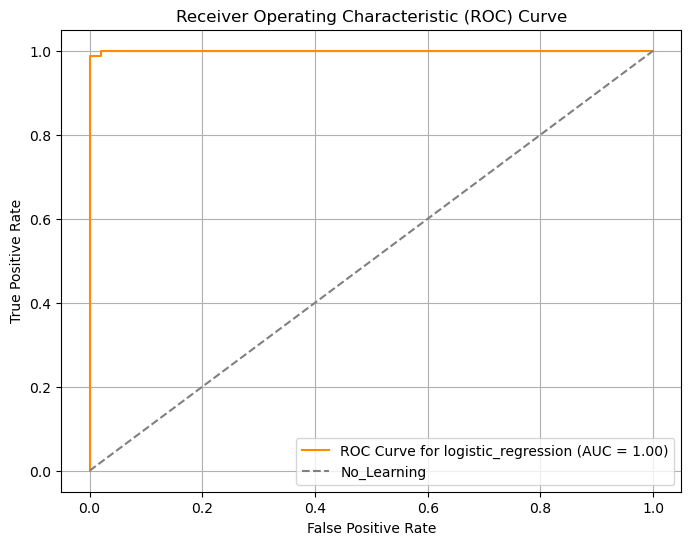

In [16]:
from sklearn.metrics import roc_curve, RocCurveDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_probs = grid.predict_proba(X_test)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot the ROC curve
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, label=f'ROC Curve for logistic_regression (AUC = {roc_auc_score(y_test, y_probs):.2f})', color='darkorange')

# Plot diagonal line with label
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='No_Learning')

# Add labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [17]:
age_input=int(input('Enter_age:'))
bp_input=int(input('Enter_bp:'))
al_input=int(input('Enter_al:'))
su_input=int(input('Enter_su:'))
bgr_input=int(input('Enter_bgr:'))
bu_input=int(input('Enter_bu:'))
sc_input=int(input('Enter_sc:'))
sod_input=int(input('Enter_sod:'))
pot_input=int(input('Enter_pot:'))
hrmo_input=int(input('Enter_hrmo:'))
pcv_input=int(input('Enter_pcv:'))
wc_input=int(input('Enter_wc:'))
rc_input=int(input('Enter_rc'))
sg_b_input=int(input('Enter_sg_b:'))
sg_c_input=int(input('Enter_sg_c:'))
sg_d_input=int(input('Enter_sg_d:'))
sg_e_input=int(input('Enter_sg_e:'))
rbc_normal_input=int(input('Enter_rbc_normal:'))
pc_normal_input=int(input('Enter_pc_normal:'))
pcc_present_input=int(input('Enter_pcc_present:'))
ba_present_input=int(input('Enter_ba_present_:'))
htn_yes_input=int(input('Enter_htn_yes:'))
dm_yes_input=int(input('Enter_dm_yes:'))
cad_yes_input=int(input('Enter_cad_yes:'))
appet_yes_input=int(input('Enter_appet_yes:'))
pe_yes_input=int(input('Enter_pe_yes:'))
ane_yes_input=int(input('Enter_ane_yes:'))

Enter_age: 60
Enter_bp: 50
Enter_al: 4
Enter_su: 4
Enter_bgr: 140
Enter_bu: 223
Enter_sc: 12
Enter_sod: 150
Enter_pot: 5
Enter_hrmo: 17
Enter_pcv: 52
Enter_wc: 12400
Enter_rc 6
Enter_sg_b: 1
Enter_sg_c: 1
Enter_sg_d: 1
Enter_sg_e: 1
Enter_rbc_normal: 0
Enter_pc_normal: 0
Enter_pcc_present: 0
Enter_ba_present_: 0
Enter_htn_yes: 0
Enter_dm_yes: 0
Enter_cad_yes: 0
Enter_appet_yes: 0
Enter_pe_yes: 0
Enter_ane_yes: 0


In [18]:
CKD_LG_Prediction=grid.predict([[age_input,bp_input,al_input,su_input,bgr_input,bu_input,
                                             sc_input,sod_input,pot_input,hrmo_input,pcv_input,wc_input,rc_input,sg_b_input,
                                             sg_c_input,sg_d_input,sg_e_input,rbc_normal_input,pc_normal_input,pcc_present_input,ba_present_input,htn_yes_input,
                                             dm_yes_input,cad_yes_input,appet_yes_input,pe_yes_input,ane_yes_input]])
print("CKD_Prediction={}".format(CKD_LG_Prediction))

CKD_Prediction=[1]


C:\Anaconda3.12.v\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [19]:
import pickle
filename="finalized_model_CKD_LogisticRegression_Classification.sav"
pickle.dump(grid,open(filename,'wb'))

In [20]:
loaded_model=pickle.load(open("finalized_model_CKD_LogisticRegression_Classification.sav",'rb'))
result=loaded_model.predict([[age_input,bp_input,al_input,su_input,bgr_input,bu_input,
                                             sc_input,sod_input,pot_input,hrmo_input,pcv_input,wc_input,rc_input,sg_b_input,
                                             sg_c_input,sg_d_input,sg_e_input,rbc_normal_input,pc_normal_input,pcc_present_input,ba_present_input,htn_yes_input,
                                             dm_yes_input,cad_yes_input,appet_yes_input,pe_yes_input,ane_yes_input]])

C:\Anaconda3.12.v\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [21]:
result

array([1])